In [1]:
from google.colab import files
uploaded = files.upload()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Total Customers:", len(df))
print("\nChurn Count:")
print(df['Churn'].value_counts())

Total Customers: 7043

Churn Count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [3]:
# Dataset details paakalaam
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Shape: (7043, 21)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           ob

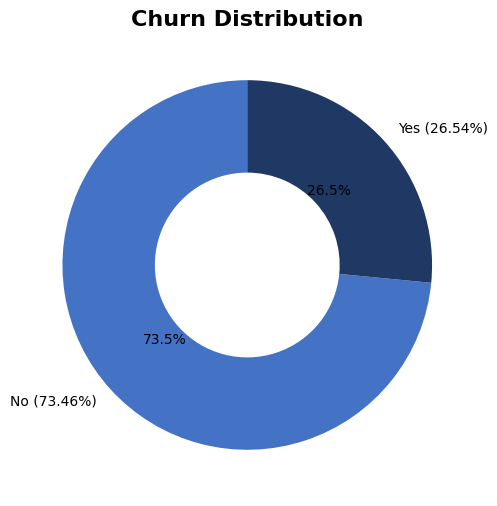

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1 - Churn Distribution (Donut chart like Power BI)
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, labels=['No (73.46%)', 'Yes (26.54%)'],
        colors=['#4472C4', '#1F3864'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'width':0.5})
plt.title('Churn Distribution', fontsize=16, fontweight='bold')
plt.show()


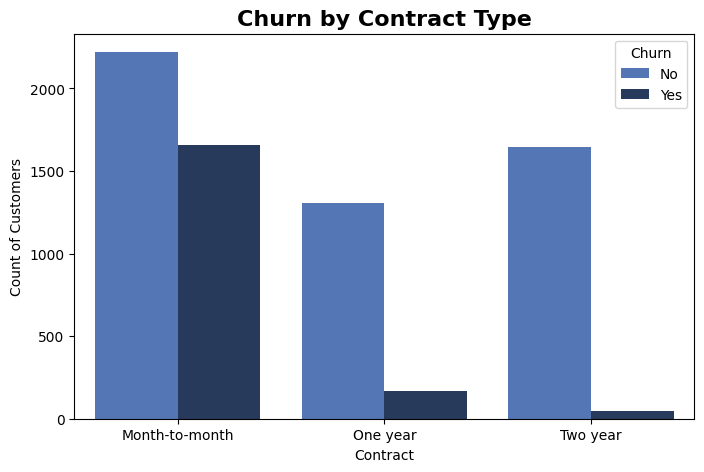

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn',
              palette=['#4472C4','#1F3864'])
plt.title('Churn by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract')
plt.ylabel('Count of Customers')
plt.legend(title='Churn')
plt.show()

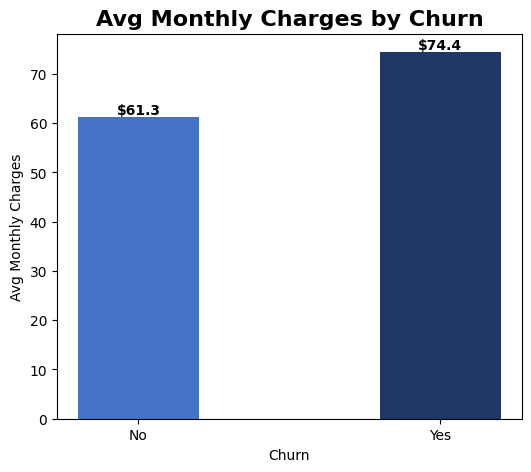

In [6]:
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean()

plt.figure(figsize=(6,5))
plt.bar(avg_charges.index, avg_charges.values,
        color=['#4472C4','#1F3864'], width=0.4)
plt.title('Avg Monthly Charges by Churn', fontsize=16, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Avg Monthly Charges')


for i, v in enumerate(avg_charges.values):
    plt.text(i, v+0.5, f'${v:.1f}', ha='center', fontweight='bold')

plt.show()

In [7]:

from sklearn.preprocessing import LabelEncoder


df_ml = df.copy()


df_ml = df_ml.drop('customerID', axis=1)


le = LabelEncoder()
for col in df_ml.columns:
    if df_ml[col].dtype == 'object':
        df_ml[col] = le.fit_transform(df_ml[col])

print("Shape:", df_ml.shape)
print("\nFirst 3 rows:")
print(df_ml.head(3))

Shape: (7043, 20)

First 3 rows:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 2            0            0                0         1   
2                 0            0            0                0         0   

   PaperlessBilling  PaymentMethod  MonthlyCharges  TotalCharges  Churn  
0                 1              2

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, classification_report


X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("✅ Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("✅ Recall:", round(recall_score(y_test, y_pred)*100, 2), "%")
print("✅ ROC-AUC:", round(roc_auc_score(y_test, y_pred)*100, 2), "%")
print("\n📊 Full Report:")
print(classification_report(y_test, y_pred))

✅ Accuracy: 79.84 %
✅ Recall: 48.53 %
✅ ROC-AUC: 69.82 %

📊 Full Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.49      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



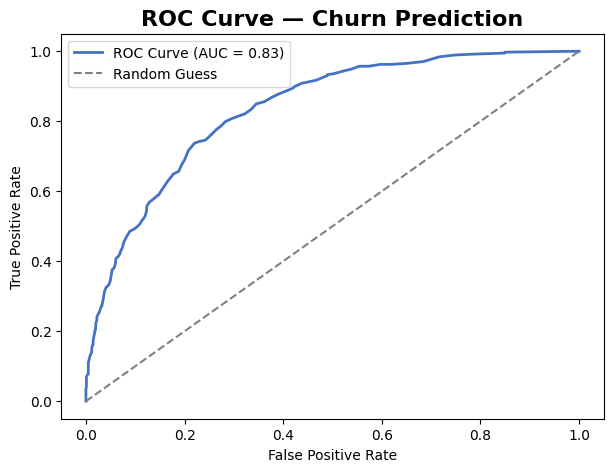

In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC Curve data
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='#4472C4', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Churn Prediction', fontsize=16, fontweight='bold')
plt.legend()
plt.show()